Bank Marketing – Customer Subscription Prediction

Introduction


The bank wants to predict whether a customer will subscribe to a term deposit based on:

Customer demographic details
Campaign information
Economic indicators

The target variable is:

y = 1 (yes) → Subscribed

y = 0 (no) → Not Subscribed

This is a Supervised Machine Learning – Classification problem.

Dataset Overview
Import required Libraries

In [3]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [4]:
#load Dataset
df = pd.read_csv("bank-additional-full.csv")   # REMOVE sep=';'

print("Dataset Loaded Successfully ✅")
print("Shape:", df.shape)
print(df.columns)


Dataset Loaded Successfully ✅
Shape: (41188, 21)
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


In [ ]:
#data Inspection

df.info()
df.describe()


Exploratory Data Analysis (EDA)

In [30]:
#Identify numerical and categorical features.

categorical = df.select_dtypes(include='object').columns
numerical = df.select_dtypes(exclude='object').columns

print("Categorical Features:", categorical)
print("Numerical Features:", numerical)


Categorical Features: Index([], dtype='object')
Numerical Features: Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_married',
       'marital_single', 'education_basic.6y', 'education_basic.9y',
       'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone',
       'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed',
       'poutcome_nonexistent', 'poutcome_success'],
      dtype='object')


In [6]:
print(df.columns)


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


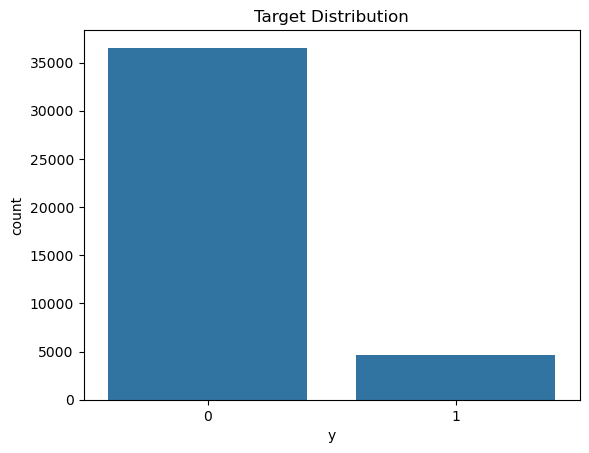

y
0    36548
1     4640
Name: count, dtype: int64


In [31]:

#Analyze the distribution of the target variable y.
sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

print(df['y'].value_counts())


Data Preprocessing

In [9]:
#Handle missing or unknown values using suitable techniques. 

print("Checking Unknown Values")
for col in categorical:
    print(col, (df[col] == 'unknown').sum())

#replace unknown with mode
for col in categorical:
    df[col] = df[col].replace('unknown', df[col].mode()[0])
print("Unknown values handled")


Checking Unknown Values
job 330
marital 80
education 1731
default 8597
housing 990
loan 990
contact 0
month 0
day_of_week 0
poutcome 0
y 0
Unknown values handled


In [10]:
#Encode categorical variables using appropriate encoding methods

df['y'] = df['y'].map({'no':0, 'yes':1})

print("Unique values in target:", df['y'].unique())


Unique values in target: [0 1]


In [11]:
#Scale numerical features where required. 

df = pd.get_dummies(df, drop_first=True)

print("Encoding Completed")
print("New Shape:", df.shape)


Encoding Completed
New Shape: (41188, 48)


In [12]:
#feature Target Split

X = df.drop('y', axis=1)
y = df['y']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (41188, 47)
Target Shape: (41188,)


In [13]:
#Split the dataset into training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (32950, 47)
Test Shape: (8238, 47)


In [14]:
#Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Completed")


Scaling Completed


Model Building

Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Completed")


Training Logistic Regression
Logistic Regression Completed


In [32]:
train_score = lr.score(X_train, y_train)
test_score = lr.score(X_test, y_test)

print("Training Accuracy:", train_score)
print("Testing Accuracy:", test_score)

Training Accuracy: 0.9117147192716236
Testing Accuracy: 0.9099295945617868


KNN

In [18]:
from sklearn.neighbors import KNeighborsClassifier

print("Training KNN")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Completed")


Training KNN
KNN Completed


In [33]:
print("Training Accuracy:", knn.score(X_train, y_train))
print("Testing Accuracy:", knn.score(X_test, y_test))

Training Accuracy: 0.9219119878603945
Testing Accuracy: 0.8983976693372178


Support Vector Machine(SVM)

In [19]:
from sklearn.svm import SVC

print("Training SVM")

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Completed")


Training SVM
SVM Completed


In [36]:
print("Training Accuracy:", svm.score(X_train, y_train))
print("Testing Accuracy:", svm.score(X_test, y_test))


Training Accuracy: 0.9255538694992412
Testing Accuracy: 0.9077445982034474


Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree")

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Completed")


Training Decision Tree
Decision Tree Completed


Ensemble Models

In [21]:
#Random Forest 
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest")

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Completed")


Training Random Forest
Random Forest Completed


In [37]:
#Boosting models (AdaBoost / Gradient Boosting) 
from sklearn.ensemble import AdaBoostClassifier

print("Training AdaBoost")

ada = AdaBoostClassifier()
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

print("AdaBoost Completed")


Training AdaBoost
AdaBoost Completed


 Model Evaluation

Evaluate all models using the following metrics: 
• Accuracy 
• Precision 
• Recall 
• F1-score 
Compare the performance of: 
• Individual models vs Ensemble models

In [24]:
def evaluate(name, y_test, y_pred):
    print(f"\nModel: {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))


In [25]:
evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("KNN", y_test, y_pred_knn)
evaluate("SVM", y_test, y_pred_svm)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("AdaBoost", y_test, y_pred_ada)

print("All Models Evaluated Successfully")



Model: Logistic Regression
Accuracy: 0.9099295945617868
Precision: 0.6595041322314049
Recall: 0.4267379679144385
F1 Score: 0.5181818181818182

Model: KNN
Accuracy: 0.8983976693372178
Precision: 0.5859649122807018
Recall: 0.3572192513368984
F1 Score: 0.44385382059800665

Model: SVM
Accuracy: 0.9077445982034474
Precision: 0.6611418047882136
Recall: 0.3839572192513369
F1 Score: 0.4857916102841678

Model: Decision Tree
Accuracy: 0.8835882495751396
Precision: 0.4879032258064516
Recall: 0.5176470588235295
F1 Score: 0.5023352361183187

Model: Random Forest
Accuracy: 0.9095654285020636
Precision: 0.6388888888888888
Recall: 0.46737967914438505
F1 Score: 0.5398394070413836

Model: AdaBoost
Accuracy: 0.9038601602330663
Precision: 0.6166394779771615
Recall: 0.4042780748663102
F1 Score: 0.4883720930232558
All Models Evaluated Successfully


Model Comparison

In [26]:
results = pd.DataFrame({
    'Model': ['LR','KNN','SVM','DT','RF','AdaBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ada)
    ]
})

results.sort_values(by='Accuracy', ascending=False)


,Model,Accuracy
0,LR,0.909930
4,RF,0.909565
2,SVM,0.907745
5,AdaBoost,0.903860
1,KNN,0.898398
3,DT,0.883588


In [28]:
importance = rf.feature_importances_
feature_names = X.columns

feature_imp = pd.Series(importance, index=feature_names)
feature_imp.sort_values(ascending=False).head(10)


duration            0.298378
euribor3m           0.096539
age                 0.093382
nr.employed         0.054707
campaign            0.044286
pdays               0.031297
poutcome_success    0.028010
cons.conf.idx       0.025175
cons.price.idx      0.023014
emp.var.rate        0.021410
dtype: float64